In [29]:
import pyml

In [30]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

# Create folder
os.makedirs("data", exist_ok=True)

# -----------------------------
# Create 30 Row Dataset
# -----------------------------

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, 30),                 # Numerical
    "Salary": np.random.randint(20000, 80000, 30),        # Numerical
    "Gender": np.random.choice(["Male", "Female"], 30),   # Categorical
    "City": np.random.choice(["Mumbai", "Pune", "Delhi"], 30),  # Categorical
    "Target": [0]*24 + [1]*6                               # Imbalance
})

# -----------------------------
# Add Null Values
# -----------------------------

# 25% null in numerical
df.loc[df.sample(frac=0.25).index, "Age"] = np.nan
df.loc[df.sample(frac=0.25).index, "Salary"] = np.nan

# 20% null in categorical
df.loc[df.sample(frac=0.2).index, "City"] = np.nan

# -----------------------------
# Add Outliers
# -----------------------------

outlier_idx = df.sample(2).index
df.loc[outlier_idx, "Salary"] = 500000  # extreme value

# -----------------------------
# Save Dataset
# -----------------------------

file_path = "data/mixed_30_dataset.csv"
df.to_csv(file_path, index=False)

print("Dataset Created Successfully ✅")
print(df)

Dataset Created Successfully ✅
     Age    Salary  Gender    City  Target
0   56.0       NaN  Female   Delhi       0
1   46.0       NaN    Male   Delhi       0
2   32.0   39118.0  Female    Pune       0
3    NaN   55773.0    Male   Delhi       0
4   38.0   73810.0  Female  Mumbai       0
5   56.0   21899.0    Male    Pune       0
6   36.0   76886.0    Male  Mumbai       0
7   40.0       NaN  Female  Mumbai       0
8   28.0   51551.0    Male    Pune       0
9   28.0   70680.0  Female     NaN       0
10  41.0  500000.0  Female  Mumbai       0
11  53.0       NaN  Female    Pune       0
12   NaN   23890.0  Female  Mumbai       0
13   NaN   61606.0  Female     NaN       0
14  20.0  500000.0  Female     NaN       0
15  39.0   34502.0  Female     NaN       0
16   NaN   41777.0  Female   Delhi       0
17  41.0   30627.0  Female  Mumbai       0
18  47.0   28792.0  Female     NaN       0
19   NaN   63323.0  Female  Mumbai       0
20  19.0       NaN    Male   Delhi       0
21  38.0   28433.0    M

In [31]:
from pyml.loader.data_loader import DataLoader

# Create loader object
loader = DataLoader()

# Auto load
data = loader.auto_load("data/mixed_30_dataset.csv")

print("\nLoaded Data Using PyML ✅")
print(data)

2026-03-01 20:54:47,059 - INFO - BaseModule initialized
2026-03-01 20:54:47,059 - INFO - DataLoader Initialized
2026-03-01 20:54:47,076 - INFO - CSV file loaded successfully.



Loaded Data Using PyML ✅
     Age    Salary  Gender    City  Target
0   56.0       NaN  Female   Delhi       0
1   46.0       NaN    Male   Delhi       0
2   32.0   39118.0  Female    Pune       0
3    NaN   55773.0    Male   Delhi       0
4   38.0   73810.0  Female  Mumbai       0
5   56.0   21899.0    Male    Pune       0
6   36.0   76886.0    Male  Mumbai       0
7   40.0       NaN  Female  Mumbai       0
8   28.0   51551.0    Male    Pune       0
9   28.0   70680.0  Female     NaN       0
10  41.0  500000.0  Female  Mumbai       0
11  53.0       NaN  Female    Pune       0
12   NaN   23890.0  Female  Mumbai       0
13   NaN   61606.0  Female     NaN       0
14  20.0  500000.0  Female     NaN       0
15  39.0   34502.0  Female     NaN       0
16   NaN   41777.0  Female   Delhi       0
17  41.0   30627.0  Female  Mumbai       0
18  47.0   28792.0  Female     NaN       0
19   NaN   63323.0  Female  Mumbai       0
20  19.0       NaN    Male   Delhi       0
21  38.0   28433.0    Male  

In [32]:
data.isnull().sum()

Age       8
Salary    8
Gender    0
City      6
Target    0
dtype: int64

In [33]:
from pyml.cleaning.missing_values import MissingValueHandler

missing_handler = MissingValueHandler()

data_clean = missing_handler.fit_transform(data)

print("Missing Values Handled ✅")
print("Remaining Missing Values:", data_clean.isnull().sum().sum())

2026-03-01 20:54:47,244 - INFO - BaseModule initialized
2026-03-01 20:54:47,244 - INFO - MissingValueHandler Initialized
2026-03-01 20:54:47,269 - INFO - Numerical missing values handled.
2026-03-01 20:54:47,281 - INFO - Categorical missing values handled.


Missing Values Handled ✅
Remaining Missing Values: 0


In [34]:
print("after pyml use handle missing values")
data.isnull().sum()


after pyml use handle missing values


Age       0
Salary    0
Gender    0
City      0
Target    0
dtype: int64

In [35]:
data.head()

,Age,Salary,Gender,City,Target
0,56.000000,90703.681818,Female,Delhi,0.0
1,46.000000,90703.681818,Male,Delhi,0.0
2,32.000000,39118.000000,Female,Pune,0.0
3,39.136364,55773.000000,Male,Delhi,0.0
4,38.000000,73810.000000,Female,Mumbai,0.0


2026-03-01 20:54:47,565 - INFO - BaseModule initialized
2026-03-01 20:54:47,565 - INFO - Advanced Visualization Engine Initialized


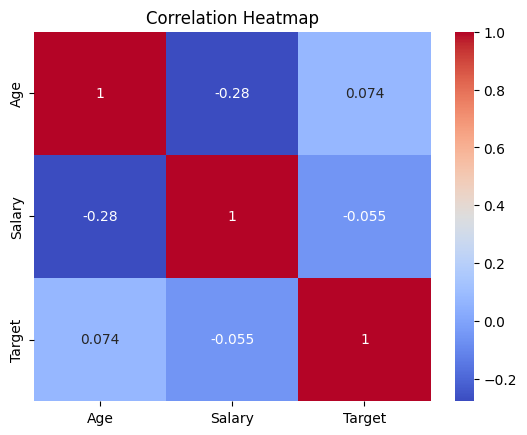

In [36]:
from pyml.visualization.plots import AdvancedVisualization

viz = AdvancedVisualization()

# Sirf numeric columns
numeric_data = data_clean.select_dtypes(include=["number"])

viz.correlation_heatmap(numeric_data)

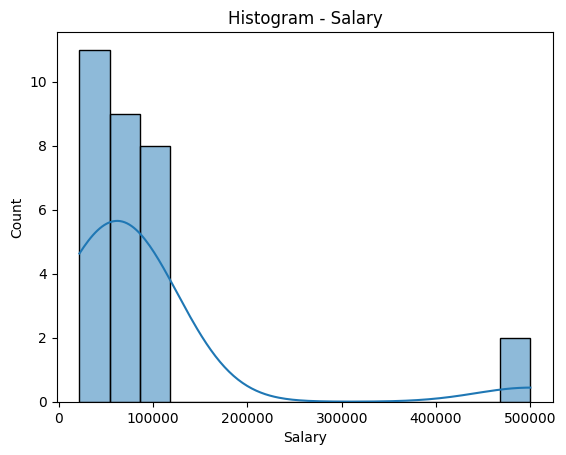

In [37]:
viz.histogram(data_clean, "Salary")

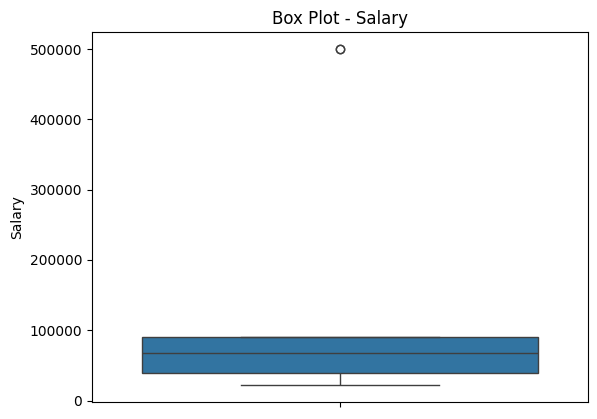

In [38]:
viz.box(data_clean, "Salary")

In [39]:
from pyml.cleaning.outliers import OutlierHandler

outlier_handler = OutlierHandler()

outliers = outlier_handler.detect_iqr(data_clean, "Salary")

print("Detected Outliers (IQR Method):")
print(outliers)

2026-03-01 20:54:49,477 - INFO - BaseModule initialized
2026-03-01 20:54:49,477 - INFO - OutlierHandler Initialized


Detected Outliers (IQR Method):
     Age    Salary  Gender    City  Target
10  41.0  500000.0  Female  Mumbai     0.0
14  20.0  500000.0  Female  Mumbai     0.0


In [40]:
data_final = outlier_handler.remove_outliers_iqr(data_clean, "Salary")

print("Outliers Removed ✅")
print("Final Dataset Shape:", data_final.shape)

2026-03-01 20:54:49,558 - INFO - Outliers removed using IQR from Salary


Outliers Removed ✅
Final Dataset Shape: (28, 5)


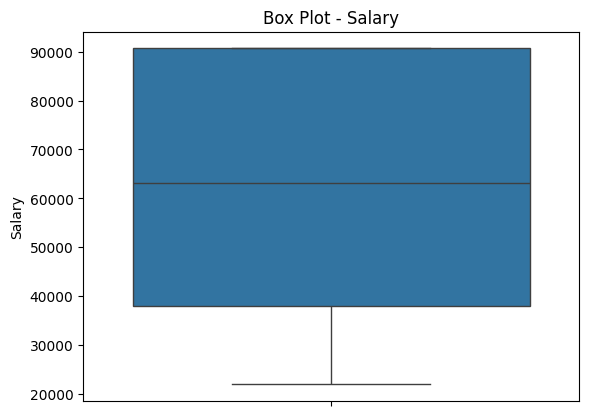

In [41]:
viz.box(data_final, "Salary")

2026-03-01 20:54:50,192 - INFO - BaseModule initialized
2026-03-01 20:54:50,200 - INFO - Advanced Visualization Engine Initialized


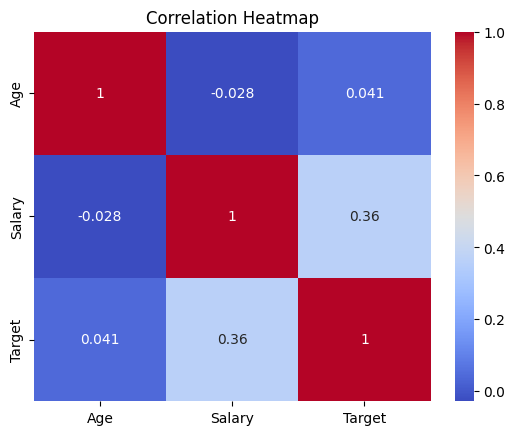

In [42]:
from pyml.visualization.plots import AdvancedVisualization

viz = AdvancedVisualization()

# Sirf numeric columns
numeric_data = data_final.select_dtypes(include=["number"])

viz.correlation_heatmap(numeric_data)

In [43]:
from pyml.preprocessing.encoding import EncodingHandler

encoder = EncodingHandler()

data_label = encoder.label_encode(data.copy())

print("Label Encoding Done ✅")
data_label.head()

2026-03-01 20:54:50,946 - INFO - BaseModule initialized
2026-03-01 20:54:50,946 - INFO - EncodingHandler Initialized
2026-03-01 20:54:50,955 - INFO - Label Encoding applied on Gender
2026-03-01 20:54:50,955 - INFO - Label Encoding applied on City


Label Encoding Done ✅


,Age,Salary,Gender,City,Target
0,56.000000,90703.681818,0,0,0.0
1,46.000000,90703.681818,1,0,0.0
2,32.000000,39118.000000,0,2,0.0
3,39.136364,55773.000000,1,0,0.0
4,38.000000,73810.000000,0,1,0.0


In [44]:
data_onehot = encoder.one_hot_encode(data.copy())

print("One Hot Encoding Done ✅")
data_onehot.head()

2026-03-01 20:54:51,045 - INFO - One Hot Encoding applied.


One Hot Encoding Done ✅


,Age,Salary,Target,Gender_Male,City_Mumbai,City_Pune
0,56.000000,90703.681818,0.0,False,False,False
1,46.000000,90703.681818,0.0,True,False,False
2,32.000000,39118.000000,0.0,False,False,True
3,39.136364,55773.000000,0.0,True,False,False
4,38.000000,73810.000000,0.0,False,True,False


In [45]:
from pyml.preprocessing.encoding import EncodingHandler

encoder = EncodingHandler()

data_encoded = encoder.one_hot_encode(data)

print("Encoding Applied ✅")
print("New Shape:", data_encoded.shape)
data_encoded.head()

2026-03-01 20:54:51,125 - INFO - BaseModule initialized
2026-03-01 20:54:51,125 - INFO - EncodingHandler Initialized
2026-03-01 20:54:51,141 - INFO - One Hot Encoding applied.


Encoding Applied ✅
New Shape: (30, 6)


,Age,Salary,Target,Gender_Male,City_Mumbai,City_Pune
0,56.000000,90703.681818,0.0,False,False,False
1,46.000000,90703.681818,0.0,True,False,False
2,32.000000,39118.000000,0.0,False,False,True
3,39.136364,55773.000000,0.0,True,False,False
4,38.000000,73810.000000,0.0,False,True,False


In [46]:
X = data_encoded.drop("Target", axis=1)
y = data_encoded["Target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (30, 5)
y Shape: (30,)


In [47]:
X = data_onehot.drop("Target", axis=1)
y = data_onehot["Target"]

from pyml.preprocessing.scaling import ScalingHandler

scaler = ScalingHandler()

X_standard = scaler.scale(X.copy(), method="standard")

print("Standard Scaling Done ✅")

2026-03-01 20:54:51,294 - INFO - BaseModule initialized
2026-03-01 20:54:51,294 - INFO - ScalingHandler Initialized
2026-03-01 20:54:51,310 - INFO - standard scaling applied.


Standard Scaling Done ✅


In [48]:
X_minmax = scaler.scale(X.copy(), method="minmax")

print("MinMax Scaling Done ✅")

2026-03-01 20:54:51,548 - INFO - minmax scaling applied.


MinMax Scaling Done ✅


In [49]:
X_robust = scaler.scale(X.copy(), method="robust")

print("Robust Scaling Done ✅")

2026-03-01 20:54:51,660 - INFO - robust scaling applied.


Robust Scaling Done ✅


In [50]:
from pyml.preprocessing.scaling import ScalingHandler

scaler = ScalingHandler()

X_scaled = scaler.scale(X, method="standard")

print("Scaling Applied ✅")
X_scaled.head()

2026-03-01 20:54:51,780 - INFO - BaseModule initialized
2026-03-01 20:54:51,780 - INFO - ScalingHandler Initialized
2026-03-01 20:54:51,796 - INFO - standard scaling applied.


Scaling Applied ✅


,Age,Salary,Gender_Male,City_Mumbai,City_Pune
0,2.032801e+00,1.300037e-16,False,False,False
1,8.273664e-01,1.300037e-16,True,False,False
2,-8.602419e-01,-4.608555e-01,False,False,True
3,-8.565127e-16,-3.120633e-01,True,False,False
4,-1.369812e-01,-1.509246e-01,False,True,False


In [51]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [52]:
# balance dataset

from pyml.preprocessing.balancing import BalancingHandler

balancer = BalancingHandler()

X_balanced, y_balanced = balancer.balance(
    X_standard,
    y,
    method="smote"
)

print("Balancing Done (SMOTE) ✅")
print("Before:")
print(y.value_counts())

print("\nAfter:")
print(y_balanced.value_counts())

2026-03-01 20:54:55,830 - INFO - BaseModule initialized
2026-03-01 20:54:55,830 - INFO - BalancingHandler Initialized
2026-03-01 20:54:55,861 - INFO - SMOTE applied successfully.


Balancing Done (SMOTE) ✅
Before:
Target
0.0    24
1.0     6
Name: count, dtype: int64

After:
Target
0.0    24
1.0    24
Name: count, dtype: int64


In [53]:
import pandas as pd

final_dataset = pd.concat([X_balanced, y_balanced], axis=1)

print("Final Shape:", final_dataset.shape)
final_dataset.head()

Final Shape: (48, 6)


,Age,Salary,Gender_Male,City_Mumbai,City_Pune,Target
0,2.032801e+00,1.300037e-16,False,False,False,0.0
1,8.273664e-01,1.300037e-16,True,False,False,0.0
2,-8.602419e-01,-4.608555e-01,False,False,True,0.0
3,-8.565127e-16,-3.120633e-01,True,False,False,0.0
4,-1.369812e-01,-1.509246e-01,False,True,False,0.0


In [54]:
from pyml.preprocessing.balancing import BalancingHandler

balancer = BalancingHandler()

X_over, y_over = balancer.balance(
    X_scaled,
    y,
    method="smote"
)

print("OverSampling (SMOTE) Done ✅")
print("After OverSampling:\n", y_over.value_counts())

2026-03-01 20:54:56,090 - INFO - BaseModule initialized
2026-03-01 20:54:56,090 - INFO - BalancingHandler Initialized
2026-03-01 20:54:56,274 - INFO - SMOTE applied successfully.


OverSampling (SMOTE) Done ✅
After OverSampling:
 Target
0.0    24
1.0    24
Name: count, dtype: int64


In [55]:
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler(random_state=42)

X_under, y_under = under.fit_resample(X_scaled, y)

print("UnderSampling Done ✅")
print("After UnderSampling:\n", y_under.value_counts())

UnderSampling Done ✅
After UnderSampling:
 Target
0.0    6
1.0    6
Name: count, dtype: int64


In [56]:
import pandas as pd

final_over = pd.concat([X_over, y_over], axis=1)
final_under = pd.concat([X_under, y_under], axis=1)

print("Final OverSampled Shape:", final_over.shape)
print("Final UnderSampled Shape:", final_under.shape)

Final OverSampled Shape: (48, 6)
Final UnderSampled Shape: (12, 6)


In [58]:
from pyml.intelligence.auto_selector import AutoModelSelector

selector = AutoModelSelector()

results = selector.compare_models(X, y)

print("Model Comparison Results:")
for r in results:
    print(r)

2026-03-01 20:58:33,954 - INFO - BaseModule initialized
2026-03-01 20:58:33,956 - INFO - BaseModule initialized
2026-03-01 20:58:33,956 - INFO - ModelEngine initialized
2026-03-01 20:58:33,956 - INFO - Auto Model Selector Initialized
2026-03-01 20:58:34,874 - INFO - Model Comparison Completed.


Model Comparison Results:
{'model': 'logistic_regression', 'score': 0.8333333333333334}
{'model': 'random_forest_classifier', 'score': 0.8333333333333334}
{'model': 'decision_tree_classifier', 'score': 0.6666666666666666}
{'model': 'kmeans', 'score': 0.0}


In [59]:
best = selector.best_model(X, y)

print("Best Model Selected:")
print(best)

2026-03-01 20:58:56,780 - INFO - Model Comparison Completed.


Best Model Selected:
{'model': 'logistic_regression', 'score': 0.8333333333333334}


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [64]:
from pyml.model.model_engine import ModelEngine

engine = ModelEngine()

best_model_name = best["model"]

model = engine.get_model(best_model_name)

model.fit(X_train, y_train)

print("Model Trained on Training Data ✅")

2026-03-01 21:04:05,523 - INFO - BaseModule initialized
2026-03-01 21:04:05,523 - INFO - ModelEngine initialized


Model Trained on Training Data ✅


In [65]:
y_pred = model.predict(X_test)

In [66]:
from pyml.evaluation.metrics import Metrics

metrics = Metrics()

report = metrics.classification_report(y_test, y_pred)

print("Classification Report:")
for key, value in report.items():
    print(f"{key}:\n{value}\n")

2026-03-01 21:04:38,111 - INFO - Evaluation Metrics Module Initialized
c:\Users\Vaibhav Patil\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-03-01 21:04:38,215 - INFO - Classification metrics calculated.


Classification Report:
accuracy:
0.8333333333333334

precision:
0.6944444444444445

recall:
0.8333333333333334

f1_score:
0.7575757575757575

confusion_matrix:
[[5 0]
 [1 0]]



In [67]:
report = metrics.regression_report(y_test, y_pred)

print("Regression Report:")
for key, value in report.items():
    print(f"{key}: {value}")

2026-03-01 21:05:10,358 - INFO - Regression metrics calculated.


Regression Report:
mae: 0.16666666666666666
mse: 0.16666666666666666
rmse: 0.408248290463863
r2_score: -0.19999999999999973


In [68]:
import numpy as np
from pyml.evaluation.metrics import Metrics

metrics = Metrics()

if len(np.unique(y)) <= 20:
    report = metrics.classification_report(y_test, y_pred)
else:
    report = metrics.regression_report(y_test, y_pred)

print(report)

2026-03-01 21:05:28,567 - INFO - Evaluation Metrics Module Initialized
c:\Users\Vaibhav Patil\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-03-01 21:05:28,628 - INFO - Classification metrics calculated.


{'accuracy': 0.8333333333333334, 'precision': 0.6944444444444445, 'recall': 0.8333333333333334, 'f1_score': 0.7575757575757575, 'confusion_matrix': array([[5, 0],
       [1, 0]])}


In [ ]:
'''from pyml.model.model_engine import ModelEngine

engine = ModelEngine()

best_model_name = best["model"]

model = engine.get_model(best_model_name)
model.fit(X, y)

print("Final Model Trained ✅")'''

2026-03-01 20:59:16,308 - INFO - BaseModule initialized
2026-03-01 20:59:16,316 - INFO - ModelEngine initialized


Final Model Trained ✅


In [62]:
import numpy as np
from pyml.evaluation.metrics import Metrics

metrics = Metrics()

if len(np.unique(y)) <= 20:
    report = metrics.classification_report(y_test, y_pred)
else:
    report = metrics.regression_report(y_test, y_pred)

print(report)

2026-03-01 21:02:53,984 - INFO - Evaluation Metrics Module Initialized


NameError: name 'y_test' is not defined